In [1]:
import os
import re
import json
import pandas as pd
import numpy as np
from tqdm import tqdm
from datetime import datetime

import seaborn as sns
from matplotlib import pyplot as plt
from matplotlib.colors import BoundaryNorm
from matplotlib.colors import ListedColormap


from patsy import dmatrices
import bambi as bmb
import arviz as az
from scipy.stats import chi2
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import display
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.outliers_influence import variance_inflation_factor

from util import *

sns.set_palette('colorblind')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

### Initialise urls

In [2]:
msnbc_urls = [
    "https://www.instagram.com/msnbc/reel/DQz6GiKkqD-/",
    "https://www.instagram.com/msnbc/reel/DQzvigyiu3R/",
    "https://www.instagram.com/msnbc/reel/DQzaxBeisq2/",
    "https://www.instagram.com/msnbc/reel/DQzOhJyil7B/",
    "https://www.instagram.com/msnbc/reel/DQx_MsXDdqz/",
    "https://www.instagram.com/reel/DQx6d6TDFvD/",
    "https://www.instagram.com/reel/DQxz17nkXAu/",
    "https://www.instagram.com/reel/DQxxwsjEQxy/",
    "https://www.instagram.com/reel/DQxf5uvERD0/",
    "https://www.instagram.com/reel/DQxc21kkqwR/",
]

huffpost_urls = [
    "https://www.instagram.com/huffpost/reel/DQzSuMQARR0/",
    "https://www.instagram.com/huffpost/p/DQxLW-PEns-/",
    "https://www.instagram.com/huffpost/reel/DQxARFuAbt-/",
    "https://www.instagram.com/huffpost/reel/DQw6Qa_kWgY/",
    "https://www.instagram.com/huffpost/reel/DQw5_xHkWod/",
    "https://www.instagram.com/huffpost/reel/DQwbCxQjQNQ/",
    "https://www.instagram.com/huffpost/p/DQu2w59E9t-/",
    "https://www.instagram.com/huffpost/reel/DQvEm2FDCmz/",
    "https://www.instagram.com/huffpost/p/DQuw7U7D322/",
    "https://www.instagram.com/p/DQujjUrk61E/"
]

cnn_urls = [
    "https://www.instagram.com/reel/DQ0VgDjjx7K/",
    # "https://www.instagram.com/p/DQ0LWj6jue3/",
    "https://www.instagram.com/reel/DQz7vqJiEUj/",
    "https://www.instagram.com/reel/DQznNr7gp1F/",
    "https://www.instagram.com/reel/DQzgXgPgPmN/",
    "https://www.instagram.com/reel/DQzNYM8ARN3/",
    "https://www.instagram.com/reel/DQzEp0pChCY/",
    "https://www.instagram.com/reel/DQy-AdiCcH_/",
    "https://www.instagram.com/reel/DQyzpQVjga4/",
    "https://www.instagram.com/reel/DQypWvmDoge/"
]

washingtonpost_urls = [
    "https://www.instagram.com/washingtonpost/p/DQ0JgL9DqcC/",
    "https://www.instagram.com/washingtonpost/p/DQz7wRODMr8/",
    "https://www.instagram.com/washingtonpost/p/DQzuD3fFJcu/",
    "https://www.instagram.com/washingtonpost/reel/DQzh-t0DSAJ/",
    "https://www.instagram.com/washingtonpost/reel/DQzgTDHAcKl/",
    "https://www.instagram.com/p/DQzZihPDiQv/",
    "https://www.instagram.com/reel/DQzSo12D1fJ/",
    "https://www.instagram.com/reel/DQzLtq3ARq3/",
    "https://www.instagram.com/p/DQxxk6BDvZh/",
    "https://www.instagram.com/p/DQxqaCpDcHC/"
]

forbes_urls = [
    "https://www.instagram.com/forbes/p/DQ0Ck-lgUxt/",
    "https://www.instagram.com/forbes/p/DQz0444AWAd/",
    "https://www.instagram.com/forbes/p/DQzgP9_gcjC/",
    "https://www.instagram.com/p/DQzUOiGAblX/",
    "https://www.instagram.com/p/DQzLpqJDxMD/",
    "https://www.instagram.com/p/DQzFWzxkT-c/",
    "https://www.instagram.com/p/DQxdypCDPF2/",
    "https://www.instagram.com/p/DQxOpmbkn_b/",
    "https://www.instagram.com/p/DQxFjBJj4gS/",
    "https://www.instagram.com/p/DQxElAzD6aK/"
]

thehill_urls = [
    "https://www.instagram.com/thehill/p/DQzfVDcE3YB/",
    "https://www.instagram.com/thehill/p/DQxg1ufkeqR/",
    "https://www.instagram.com/thehill/reel/DQxViLFEdQ5/",
    "https://www.instagram.com/thehill/p/DQw1LZxEwrn/",
    "https://www.instagram.com/thehill/p/DQwgkZxD2Ug/",
    "https://www.instagram.com/thehill/reel/DQvAK9hEeWU/",
    "https://www.instagram.com/thehill/p/DQunQLokn-7/",
    "https://www.instagram.com/thehill/reel/DQuNa5zEeiR/",
    "https://www.instagram.com/thehill/p/DQt9lxsjumG/",
    "https://www.instagram.com/reel/DQrpC35EXqn/"
]

washingtontimes_urls = [
    "https://www.instagram.com/washtimes/p/DQz0CxJExjr/",
    "https://www.instagram.com/washtimes/p/DQzcWsGkg8C/",
    "https://www.instagram.com/washtimes/p/DQxHICQE_29/",
    "https://www.instagram.com/washtimes/p/DQw_V8sE6ZH/",
    "https://www.instagram.com/washtimes/p/DQw3jz6k0L6/",
    "https://www.instagram.com/washtimes/p/DQwvq-dktiv/",
    "https://www.instagram.com/washtimes/p/DQwn4b2EzCR/",
    "https://www.instagram.com/washtimes/p/DQwgGZ2jQck/",
    "https://www.instagram.com/washtimes/p/DQvCB1iEwBa/",
    "https://www.instagram.com/washtimes/reel/DQu5zA1CL3U/"
]

nypost_urls = [
    "https://www.instagram.com/p/DQ0Jd_SAc4Z/",
    "https://www.instagram.com/p/DQ0GBAngWyx/",
    "https://www.instagram.com/reel/DQ0ETkoDtLN/",
    "https://www.instagram.com/p/DQ0ClEugU1r/",
    "https://www.instagram.com/p/DQz_JRkAWr9/",
    "https://www.instagram.com/reel/DQz9kQIDZOc/",
    "https://www.instagram.com/p/DQz70tPAQTn/",
    "https://www.instagram.com/p/DQz4Y1Xgadc/",
    "https://www.instagram.com/reel/DQz2rWGEkpe/",
    "https://www.instagram.com/p/DQz09vagSe1/"
]

foxnews_urls = [
    "https://www.instagram.com/reel/DQ0V_qAEfwE/",
    "https://www.instagram.com/reel/DQ0UdiODE-2/",
    "https://www.instagram.com/reel/DQ0UNIZD3rv/",
    "https://www.instagram.com/reel/DQ0OfgWAswZ/",
    "https://www.instagram.com/reel/DQ0OAwCk91U/",
    "https://www.instagram.com/reel/DQ0GaXEjofE/",
    "https://www.instagram.com/reel/DQ0ClztkmYz/",
    "https://www.instagram.com/p/DQ0AYUTkvh4/",
    "https://www.instagram.com/p/DQz8ZTUjJ4s/",
    "https://www.instagram.com/reel/DQz8UW2j4TQ/"
]

breitbart_urls = [
    "https://www.instagram.com/p/DQ0P_UtDFLj/",
    "https://www.instagram.com/p/DQ0ImR1DaM0/",
    "https://www.instagram.com/p/DQz28XJkuQV/",
    "https://www.instagram.com/p/DQzkN12CUZQ/",
    "https://www.instagram.com/reel/DQzXuPOkgOo/",
    "https://www.instagram.com/p/DQzR5CjkQxS/",
    "https://www.instagram.com/p/DQzJCenDSPC/",
    "https://www.instagram.com/p/DQy1VfcETEi/",
    "https://www.instagram.com/reel/DQxZ3LCkvgh/",
    "https://www.instagram.com/p/DQxfi8JjVGb/"
]

news_urls = {
    'msnbc': msnbc_urls,
    'huffpost': huffpost_urls,
    'cnn': cnn_urls,
    'washingtonpost': washingtonpost_urls,
    'forbes': forbes_urls,
    'thehill': thehill_urls,
    'washingtontimes': washingtontimes_urls,
    'nypost': nypost_urls,
    'foxnews': foxnews_urls,
    'breitbart': breitbart_urls
}

In [3]:
peacock_urls = [
    'https://www.instagram.com/peacock/reel/DSEC7pojf3H/',
    'https://www.instagram.com/peacock/reel/DSEFSQJAGeV/',
    'https://www.instagram.com/peacock/p/DSD45vFgDBd/',
    'https://www.instagram.com/peacock/reel/DSDUvgsgLqk/',
    'https://www.instagram.com/belairpeacock/reel/DSDOHnBCS0t/',
    'https://www.instagram.com/nbc/reel/DSDOHj2kr00/',
    'https://www.instagram.com/spotify/reel/DSDN0oCDkGb/',
    'https://www.instagram.com/peacock/p/DSDAUdIgDUw/',
    'https://www.instagram.com/peacock/reel/DSBm_S8gC1p/',
    'https://www.instagram.com/peacock/reel/DSBZZEcgL4D/',
]

nytcooking_urls = [
    'https://www.instagram.com/nytcooking/reel/DSD_gy1DcX5/',
    'https://www.instagram.com/nytcooking/p/DSDwcgkk1qn/',
    'https://www.instagram.com/nytcooking/p/DSDitvpAZUH/',
    'https://www.instagram.com/nytcooking/p/DSDb1UoknQg/',
    'https://www.instagram.com/nytcooking/p/DSDU8zokpV3/',
    'https://www.instagram.com/nytcooking/p/DSDOaPWk4bv/',
    'https://www.instagram.com/nytcooking/p/DSDSO3Fkwax/',
    'https://www.instagram.com/nytcooking/reel/DSDNChjDjIB/',
    'https://www.instagram.com/nytcooking/p/DSC_QAgks4q/',
    'https://www.instagram.com/nytcooking/p/DSDBAbzjifA/',
]

espn_urls = [
    'https://www.instagram.com/espn/reel/DSEgVgeAPWE/',
    'https://www.instagram.com/espncfb/p/DSEWMX5jGnh/',
    'https://www.instagram.com/espn/reel/DSEVBjZAOdU/',
    'https://www.instagram.com/espn/p/DSEOlBoDCRb/',
    'https://www.instagram.com/espn/p/DSEMouEjLXr/',
    'https://www.instagram.com/espn/p/DSELB0fjEiG/',
    'https://www.instagram.com/espn/p/DSEIW-zjJXe/',
    'https://www.instagram.com/espn/p/DSD6pTxgdJv/',
    'https://www.instagram.com/espn/p/DSDrfEyDxs-/',
    'https://www.instagram.com/espn/p/DSDjBkeEiVo/',
]

catloversclub_urls = [
    'https://www.instagram.com/catloversclub/reel/DSEn813Eo5Q/',
    'https://www.instagram.com/catloversclub/reel/DSEHOC8kufg/',
    'https://www.instagram.com/catloversclub/p/DSDzLhlkniQ/',
    'https://www.instagram.com/catloversclub/p/DSC60BKkrYV/',
    'https://www.instagram.com/catloversclub/reel/DSBk9RQEmtF/',
    'https://www.instagram.com/catloversclub/p/DSBQuBCEg6f/',
    'https://www.instagram.com/catloversclub/p/DSARqDnEhPJ/',
    'https://www.instagram.com/catloversclub/p/DR_mqpKEr01/',
    'https://www.instagram.com/catloversclub/reel/DR_fCEnEmtA/',
    'https://www.instagram.com/catloversclub/p/DR-_MPRkurr/',
]

thedogist_urls = [
    'https://www.instagram.com/thedogist/p/DSDe6u8kS6O/',
    'https://www.instagram.com/thedogist/reel/DR-aHhzkXgF/',
    'https://www.instagram.com/thedogist/reel/DR72mfKEedE/',
    'https://www.instagram.com/empirestatebldg/reel/DR7aTBTkebB/',
    'https://www.instagram.com/thedogist/p/DR5O3P_jycm/',
    'https://www.instagram.com/thedogist/reel/DR4mTwyESDm/',
    'https://www.instagram.com/thedogist/reel/DR2VEONkdPT/',
    'https://www.instagram.com/thedogist/reel/DRw-IF6EaT_/',
    'https://www.instagram.com/thedogist/p/DRqGWbcEVvW/',
    'https://www.instagram.com/thedogist/reel/DRnCa95EcVk/',
]

thegradecricketer = [
    'https://www.instagram.com/thegradecricketer/reel/DSEuOIXEsI6/',
    'https://www.instagram.com/thegradecricketer/reel/DSERcMKEs-k/',
    'https://www.instagram.com/thegradecricketer/reel/DSEC3JekvxZ/',
    'https://www.instagram.com/thegradecricketer/reel/DSCJfZ8jKrQ/',
    'https://www.instagram.com/kayosports/reel/DSB-wRmE6MH/',
    'https://www.instagram.com/triplemcricket/reel/DR_3mtdjCre/',
    'https://www.instagram.com/thegradecricketer/reel/DR_CMYYku_p/',
    'https://www.instagram.com/thegradecricketer/reel/DR9nU3FkhGV/',
    'https://www.instagram.com/thegradecricketer/reel/DR7tgNXgCeL/',
    'https://www.instagram.com/thegradecricketer/reel/DR5bFbrgFP0/',
]

pbsfood_urls = [
    'https://www.instagram.com/pbsfood/reel/DSC5fCjiBkw/',
    'https://www.instagram.com/pbsfood/p/DSAwJ9ZjgfK/',
    'https://www.instagram.com/pbsfood/p/DR99nxribK5/',
    'https://www.instagram.com/pbssocal/reel/DR2_SXGlN-b/',
    'https://www.instagram.com/pbsfood/p/DR2tagbj4NN/',
    'https://www.instagram.com/pbsfood/reel/DRzxYwWFLrA/',
    'https://www.instagram.com/pbsfood/p/DRr1KVSDQDY/',
    'https://www.instagram.com/pbsfood/p/DRmrnTCj0Uc/',
    'https://www.instagram.com/pbsfood/reel/DRkSd-jAfYR/',
    'https://www.instagram.com/pbsfood/p/DRkATf0DWKW/',
]

hulu_urls = [
    'https://www.instagram.com/hulu/reel/DSD-0GpEVyJ/',
    'https://www.instagram.com/hulu/reel/DSDb1_QCpwm/',
    'https://www.instagram.com/hulu/p/DSDPdCDja0P/',
    'https://www.instagram.com/hulu/reel/DSDAUFlkyrO/',
    'https://www.instagram.com/percyseries/reel/DSDNXoPjue0/',
    'https://www.instagram.com/freeform/reel/DSAz8SxDsaI/',
    'https://www.instagram.com/hulu/p/DSBtohckS3R/',
    'https://www.instagram.com/kumailn/reel/DSBN7auEbAo/',
    'https://www.instagram.com/hulu/reel/DSBAnzeFae5/',
    'https://www.instagram.com/getspectrum/reel/DSA91c8EeIY/',
]

ladbible_urls = [
    'https://www.instagram.com/ladbible/p/DSCrwGuDxUR/',
    'https://www.instagram.com/ladbible/reel/DSCoNYQDAK-/',
    'https://www.instagram.com/ladbible/p/DSCd_wJABTo/',
    'https://www.instagram.com/ladbible/p/DSA3Yh7ACwc/',
    'https://www.instagram.com/sportbible/p/DSAzKDHjI_T/',
    'https://www.instagram.com/sportbible/p/DSAwJA8kctO/',
    'https://www.instagram.com/ladbible/reel/DSApUwzlTf_/',
    'https://www.instagram.com/ladbible/p/DSAic0ZEhfR/',
    'https://www.instagram.com/ladbible/p/DSAYaLiE0TC/',
    'https://www.instagram.com/ladbible/p/DSAG9sXk1Fn/',
]

accesshollywood_urls = [
    'https://www.instagram.com/accesshollywood/reel/DSEBiASCUPH/',
    'https://www.instagram.com/accesshollywood/p/DSD1KHYkXtU/',
    'https://www.instagram.com/accesshollywood/reel/DSDirU6EkO2/',
    'https://www.instagram.com/accesshollywood/p/DSDU9GlDmn4/',
    'https://www.instagram.com/accesshollywood/reel/DSDKXfBCjPl/',
    'https://www.instagram.com/accesshollywood/p/DSC5lsdkySq/',
    'https://www.instagram.com/accesshollywood/reel/DSB-0hjkQNx/',
    'https://www.instagram.com/accesshollywood/reel/DSBnCAXiIL3/',
    'https://www.instagram.com/accesshollywood/reel/DSBZVIJjRta/',
    'https://www.instagram.com/accesshollywood/p/DSBAeqRk4is/',
]

nonnews_urls = {
    'peacock': peacock_urls,
    'nytcooking': nytcooking_urls,
    'espn': espn_urls,
    'catloversclub': catloversclub_urls,
    'thedogist': thedogist_urls,
    'thegradecricketer': thegradecricketer,
    'pbsfood': pbsfood_urls,
    'hulu': hulu_urls,
    'ladbible': ladbible_urls,
    'accesshollywood': accesshollywood_urls
}

In [4]:
all_crawls = ['male_dem_ny_1', 'male_dem_texas_1',
              'male_rep_ny_1', 'male_rep_texas_1',
              'female_dem_ny_1', 'female_dem_texas_1',
              'female_rep_ny_1', 'female_rep_texas_1']

# all_crawls = ['ny_1', 'texas_1',
#               'male_dem_ny_1', 'male_dem_texas_1',
#               'male_rep_ny_1', 'male_rep_texas_1',
#               'female_dem_ny_1', 'female_dem_texas_1',
#               'female_rep_ny_1', 'female_rep_texas_1']

file_path = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/new'

### Merging and preprocessing

In [8]:
flag = 'nonnews'

if flag == 'news':
    all_urls = news_urls.copy()
elif flag == 'nonnews':
    all_urls = nonnews_urls.copy()

In [9]:
dfs = {}
for crawl in all_crawls:
    temp_list = []
    for account in all_urls.keys():

        accountfiles = os.listdir(f'{file_path}/{crawl}/{account}')
        file_ids = list({re.split(r'_(comments|timestamps)', fp)[0] for fp in accountfiles})

        for id_ in file_ids:

            # if both comments and timestamps files are present
            if f'{id_}_comments.json' in accountfiles and f'{id_}_timestamps.json' in accountfiles:

                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)
                with open(f'{file_path}/{crawl}/{account}/{id_}_timestamps.json', 'r') as f:
                    timestamps = json.load(f)
                
                caption, comments, likes = clean_comments(comments)

                # this particular comment is just ' '. so adding it manually.
                id_user_mapping = {
                    'DRVQXcWAaaw': 'authoryuccaharris',
                    'DSBZZEcgL4D': 'mafia__460mafia_', 
                    'DSBm_S8gC1p': 'grimreaper3716',
                    'DRYdTZHjT-E': 'danieleichenlaub',
                    'DSARqDnEhPJ': 'amadeoedgardof',
                    'DR_mqpKEr01': 'amadeoedgardof',
                    'DSC60BKkrYV': 'amadeoedgardof',
                    'DR5O3P_jycm': 'dottyeroth',
                    'DSCrwGuDxUR': 'treqpimento_',
                    'DSEn813Eo5Q': 'amadeoedgardof'

                }

                if id_ in id_user_mapping:
                    if id_user_mapping[id_] in comments:
                        idx = comments.index(id_user_mapping[id_])
                        comments = comments[:idx+1] + [' '] + comments[idx+1:]

                # mapping usernames and comments to timestamps
                comments_map = {}

                # checking if comments (username + comment) and timestamps are of same length 
                if len(comments) == 2*len(timestamps):

                    if len(comments) % 2 == 0:

                        usernames = comments[::2]
                        comments_text = comments[1::2]

                        
                        for u, c, t in zip(usernames, comments_text, timestamps):
                            comments_map[(u, c)] = t

                        idx = 0
                        for c, v in comments_map.items():
                            temp_dict = {'account': account,
                                         'urlid': id_,
                                         'caption': caption,
                                         'comment_num': idx,
                                         f'{crawl}_comment': c,
                                         f'{crawl}_timestamp': v,
                                         'likes': likes} # TODO: check if likes here is correct
                            idx += 1
                            temp_list.append(temp_dict)

                else:
                    # if this happens, its mostly happening since a comment is empty string ''
                    print(f'comemnts-timestamps length mismatch', account, id_, crawl)
            else:
                # only comments file is present
                with open(f'{file_path}/{crawl}/{account}/{id_}_comments.json', 'r') as f:
                    comments = json.load(f)

                caption, comments, likes = clean_comments(comments)
                if len(comments) != 0:
                    if id_ == 'DSC60BKkrYV':
                        caption, comments, likes = None, [], None
                    else:
                        print('no timestamp file and len(comments) != 0', id_, account, crawl, len(comments))
                    
                    # if this happens its usually to do more cleaning of comements

    df = pd.DataFrame(temp_list)
    dfs[crawl] = df

In [10]:
for crawl, df in dfs.items():
    print(f'{crawl}: {df.shape}')

male_dem_ny_1: (1087, 7)
male_dem_texas_1: (1118, 7)
male_rep_ny_1: (1114, 7)
male_rep_texas_1: (1098, 7)
female_dem_ny_1: (1095, 7)
female_dem_texas_1: (1087, 7)
female_rep_ny_1: (1082, 7)
female_rep_texas_1: (1080, 7)


In [11]:
for crawl, df in dfs.items():
    # df.drop(columns=['likes'], inplace=True, axis=1)
    df.drop(columns=['caption', 'likes'], inplace=True, axis=1)

In [12]:
col1 = 'male_dem_ny_1'
merged_df = dfs[col1].copy()

for crawl, df in dfs.items():
    if crawl == col1:
        continue
    print(crawl)
    merged_df = pd.merge(merged_df, df, how='outer', on=['account', 'urlid', 'comment_num'])

male_dem_texas_1
male_rep_ny_1
male_rep_texas_1
female_dem_ny_1
female_dem_texas_1
female_rep_ny_1
female_rep_texas_1


In [13]:
# remove urls that have less than 10 comments

urlids = merged_df['urlid'].unique().tolist()
donotremove_urls = set()
for urlid in urlids:
    temp = merged_df[merged_df['urlid'] == urlid]
    num_rows = temp['comment_num'].max()
    if num_rows <= 8:
        continue
    else:
        donotremove_urls.add(urlid)

merged_df = merged_df[merged_df['urlid'].isin(donotremove_urls)]

In [14]:
# limiting to top 10 comments
merged_df = merged_df[merged_df['comment_num'] <= 9]
merged_df.shape

(770, 19)

In [15]:
temp_df = get_chronological_order_comments(merged_df, all_urls, all_crawls)
merged_df = pd.merge(merged_df, temp_df, how='outer', on=['account', 'urlid', 'comment_num'])

In [16]:
merged_df.drop(columns=[x for x in merged_df.columns if 'timestamp' in x], inplace=True)
merged_df.head()

,account,urlid,comment_num,male_dem_ny_1_comment,male_dem_texas_1_comment,male_rep_ny_1_comment,male_rep_texas_1_comment,female_dem_ny_1_comment,female_dem_texas_1_comment,female_rep_ny_1_comment,female_rep_texas_1_comment,chronological_comment
0,accesshollywood,DSB-0hjkQNx,0,"(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(ericalex06, 😂😂😂😂👏👏)","(debmarie5, Why so much orange on him)"
1,accesshollywood,DSB-0hjkQNx,1,"(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)"
2,accesshollywood,DSB-0hjkQNx,2,"(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(timothee_chalamet_mx, 🔥❤️😍)","(mindi.bro, Pickleball?)","(mindi.bro, Pickleball?)","(ericalex06, 😂😂😂😂👏👏)"
3,accesshollywood,DSB-0hjkQNx,3,"(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(taosphotogirl22, Clearly, yes, we do.)"
4,accesshollywood,DSB-0hjkQNx,4,"(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(growing_up_with_timothee, Definitely 😍🧡)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)","(persona_tiffany, I love it 👏👏)"


In [17]:
merged_df.shape

(1037, 12)

In [18]:
merged_df.to_csv(f'/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_{flag}.csv', index=False)

### Descriptive differences between News and Non-News accounts

In [5]:
news_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news.csv'
nonnews_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews.csv'

news_df = pd.read_csv(news_filepath)
nonnews_df = pd.read_csv(nonnews_filepath)

In [9]:
news_df

,account,urlid,comment_num,male_dem_ny_1_comment,male_dem_texas_1_comment,male_rep_ny_1_comment,male_rep_texas_1_comment,female_dem_ny_1_comment,female_dem_texas_1_comment,female_rep_ny_1_comment,female_rep_texas_1_comment,chronological_comment
0,breitbart,DRWBiQXDG0H,0,"('torinejudith', '❤️')","('torinejudith', '❤️')","('torinejudith', '❤️')","('torinejudith', '❤️')","('torinejudith', '❤️')","('torinejudith', '❤️')","('torinejudith', '❤️')","('torinejudith', '❤️')","('ryan.smith202', 'It’s not fissures in MAGA, ..."
1,breitbart,DRWBiQXDG0H,1,"('terp00', 'Maga died when trump went Israel f...","('terp00', 'Maga died when trump went Israel f...","('scottishlyme', 'The actual LEFT should be ca...","('scottishlyme', 'The actual LEFT should be ca...","('terp00', 'Maga died when trump went Israel f...","('terp00', 'Maga died when trump went Israel f...","('scottishlyme', 'The actual LEFT should be ca...","('scottishlyme', 'The actual LEFT should be ca...","('terp00', 'Maga died when trump went Israel f..."
2,breitbart,DRWBiQXDG0H,2,"('scottishlyme', 'The actual LEFT should be ca...","('scottishlyme', 'The actual LEFT should be ca...","('terp00', 'Maga died when trump went Israel f...","('terp00', 'Maga died when trump went Israel f...","('scottishlyme', 'The actual LEFT should be ca...","('scottishlyme', 'The actual LEFT should be ca...","('terp00', 'Maga died when trump went Israel f...","('terp00', 'Maga died when trump went Israel f...","('_taco_______', '🤡🤡')"
3,breitbart,DRWBiQXDG0H,3,"('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...","('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...","('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...","('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...","('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...","('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...","('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...","('i_tr00per', 'WE ARE NOT COMING TOGETHER UNTI...","('loretta.bauer.35', 'I thought that was exact..."
4,breitbart,DRWBiQXDG0H,4,"('loretta.bauer.35', 'I thought that was exact...","('loretta.bauer.35', 'I thought that was exact...","('loretta.bauer.35', 'I thought that was exact...","('loretta.bauer.35', 'I thought that was exact...","('i_tr00per', 'Bernie Moreno has the most reme...","('i_tr00per', 'Bernie Moreno has the most reme...","('i_tr00per', 'Bernie Moreno has the most reme...","('loretta.bauer.35', 'I thought that was exact...","('torinejudith', '❤️')"
...,...,...,...,...,...,...,...,...,...,...,...,...
975,washingtonpost,DRYMvrrFks8,6,"('nd3', 'Take the money out of politics! Simpl...","('nd3', 'Take the money out of politics! Simpl...","('brianmpalmieri', 'We need to take back at le...","('brianmpalmieri', 'We need to take back at le...","('jim.emerick.9', 'They are 50% of maga donors...","('jim.emerick.9', 'They are 50% of maga donors...","('nd3', 'Take the money out of politics! Simpl...","('nd3', 'Take the money out of politics! Simpl...","('nd3', 'Take the money out of politics! Simpl..."
976,washingtonpost,DRYMvrrFks8,7,"('ichills1', 'Absolutely. The greatest threat ...","('ichills1', 'Absolutely. The greatest threat ...","('ichills1', 'Absolutely. The greatest threat ...","('ichills1', 'Absolutely. The greatest threat ...","('ichills1', 'Absolutely. The greatest threat ...","('ichills1', 'Absolutely. The greatest threat ...","('ichills1', 'Absolutely. The greatest threat ...","('ichills1', 'Absolutely. The greatest threat ...","('tylerlizenby', 'It costs less than 10% of th..."
977,washingtonpost,DRYMvrrFks8,8,"('jim.emerick.9', 'They are 50% of maga donors...","('jim.emerick.9', 'They are 50% of maga donors...","('beachmom113', 'Greed.')","('beachmom113', 'Greed.')","('beachmom113', 'Greed.')","('beachmom113', 'Greed.')","('beachmom113', 'Greed.')","('beachmom113', 'Greed.')","('tessakaneene', ""We know, babe. We've known."")"
978,washingtonpost,DRYMvrrFks8,9,"('beachmom113', 'Greed.')","('beachmom113', 'Greed.')","('nd3', 'Take the money out of politics! Simpl...","('

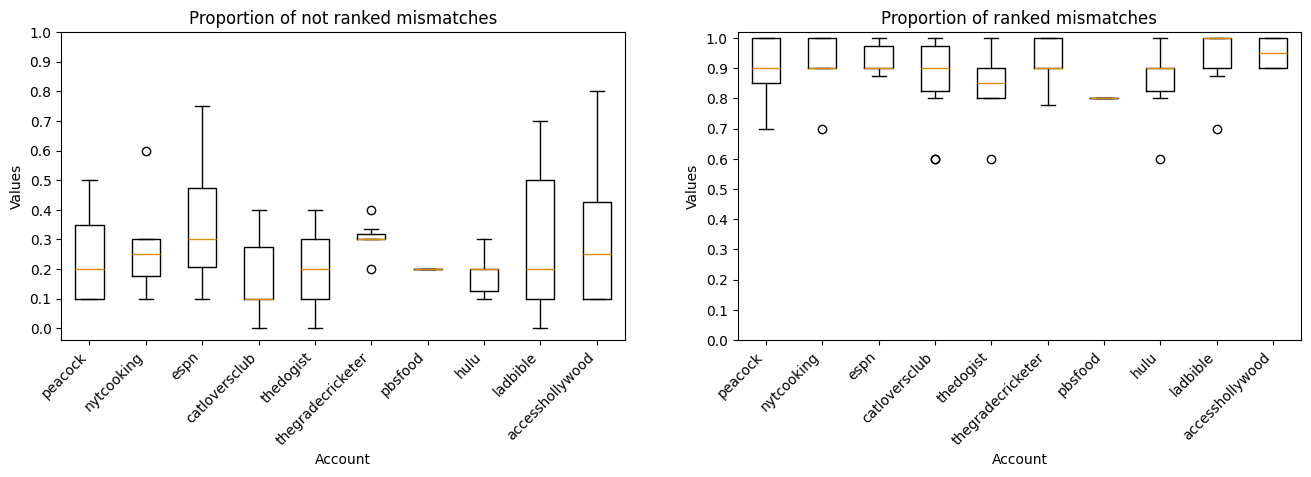

In [27]:
flag = 'nonnews'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

crawl1 = 'chronological'
crawl2 = 'male_dem_ny_1'

temp_df = plot_df.copy()
account_fprops_no_rank, account_fprops_rank, temp_df = compute_fprops(crawl1, crawl2, temp_df, plot_urls)


accounts = list(account_fprops_no_rank.keys())
values_no_rank = [account_fprops_no_rank[acc] for acc in accounts]
values_rank = [account_fprops_rank[acc] for acc in accounts]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 4))

ax1.boxplot(values_no_rank, tick_labels=accounts)
ax1.set_title("Proportion of not ranked mismatches")
ax1.set_xlabel("Account")
ax1.set_ylabel("Values")
ax1.set_xticks(range(1, 11))
ax1.set_xticklabels(accounts, rotation=45, ha='right')
ax1.set_yticks(np.arange(0, 1.1, 0.1))

ax2.boxplot(values_rank, tick_labels=accounts)
ax2.set_title("Proportion of ranked mismatches")
ax2.set_xlabel("Account")
ax2.set_ylabel("Values")
ax2.set_xticks(range(1, 11))
ax2.set_xticklabels(accounts, rotation=45, ha='right')
ax2.set_yticks(np.arange(0, 1.1, 0.1))

plt.show()

division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRX7mPtkhbo 0 0
division by zero msnbc DRXeikNDutF 0 0
division by zero msnbc DRXyanzDw2z 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRX7mPtkhbo 0 0
division by zero msnbc DRXeikNDutF 0 0
division by zero msnbc DRXyanzDw2z 0 0
division by zero msnbc DRYGzcyEsGL 0 0


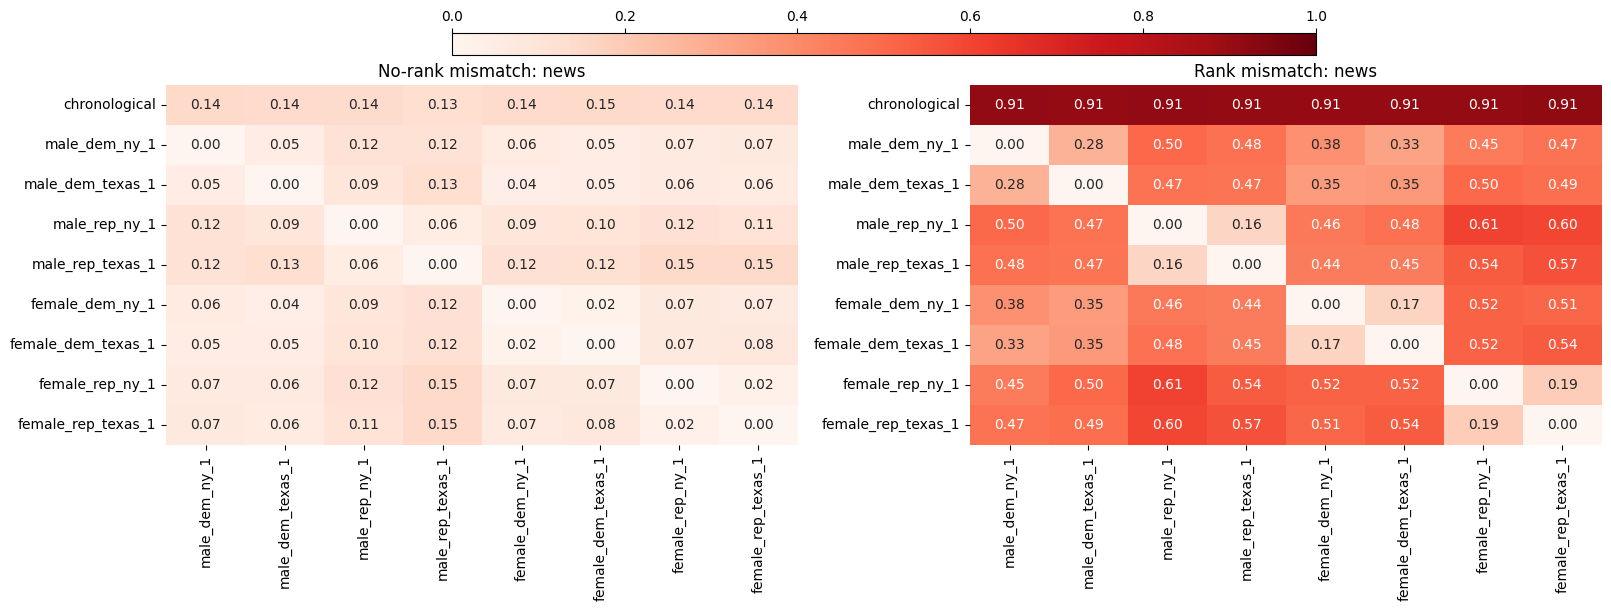

In [30]:
flag = 'news'

if flag == 'news':
    plot_df = news_df.copy()
    plot_urls = news_urls.copy()
elif flag == 'nonnews':
    plot_df = nonnews_df.copy()
    plot_urls = nonnews_urls.copy() 
else:
    raise(KeyError)

mismatch_no_rank, mismatch_rank = {}, {}

for crawl1 in ['chronological'] + all_crawls:
    mismatch_no_rank[crawl1] = {}
    mismatch_rank[crawl1] = {}
    for crawl2 in all_crawls:
        mod_df = plot_df.copy()
        _, _, mod_df = compute_fprops(crawl1, crawl2, mod_df, plot_urls)

        temp_df = mod_df[mod_df['comment_num'] == 0]
        mismatch_no_rank[crawl1][crawl2] = temp_df['fcount_no_rank'].sum() / temp_df['ftrials_no_rank'].sum()
        mismatch_rank[crawl1][crawl2] = temp_df['fcount_rank'].sum() / temp_df['ftrials_rank'].sum()

mismatch_rank_df = pd.DataFrame.from_dict(mismatch_rank, orient="index")
mismatch_no_rank_df = pd.DataFrame.from_dict(mismatch_no_rank, orient="index")


fig, axes = plt.subplots(1, 2, figsize=(16, 6), constrained_layout=True)

hm0 = sns.heatmap(
    mismatch_no_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[0], cbar=False
)
axes[0].set_title(f"No-rank mismatch: {flag}")

hm1 = sns.heatmap(
    mismatch_rank_df, annot=True, fmt=".2f",
    cmap="Reds", vmin=0, vmax=1,
    ax=axes[1], cbar=False
)
axes[1].set_title(f"Rank mismatch: {flag}")

cbar = fig.colorbar(
    hm0.collections[0],
    ax=axes,
    orientation="horizontal",
    location="top", 
    pad=0.02,
    fraction=0.06,
    aspect=40
)
cbar.ax.xaxis.set_ticks_position("top")
cbar.ax.xaxis.set_label_position("top")

plt.show()


### Regression Analysis

In [5]:
news_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_news.csv'
nonnews_filepath = '/Users/brahmaninutakki/saarland/insta-comments/saved_data/merged_data_nonnews.csv'

news_df = pd.read_csv(news_filepath)
nonnews_df = pd.read_csv(nonnews_filepath)

In [6]:
reg_news_df = get_df_for_regression(news_df, news_urls, all_crawls)
reg_nonnews_df = get_df_for_regression(nonnews_df, nonnews_urls, all_crawls)

division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero msnbc DRX71AeCgTh 0 0
division by zero msnbc DRYGzcyEsGL 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 0
division by zero catloversclub DSC60BKkrYV 0 

In [7]:
reg_news_df.shape, reg_nonnews_df.shape

((4648, 9), (4312, 9))

In [8]:
reg_news_df.drop_duplicates(inplace=True)
reg_nonnews_df.drop_duplicates(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2121, 9), (2089, 9))

In [9]:
reg_news_df.dropna(inplace=True)
reg_nonnews_df.dropna(inplace=True)

reg_news_df.shape, reg_nonnews_df.shape

((2121, 9), (2089, 9))

In [10]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_NonPolitical_Accounts')
accounts_data.head(3)

reg_nonnews_df = pd.merge(reg_nonnews_df, accounts_data, on='account', how='inner')
reg_nonnews_df.shape

(2089, 12)

In [11]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Reduced_Political_Accounts')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='account', how='inner')
reg_news_df.shape

(2121, 15)

In [12]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_nonnews.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_nonnews_df = reg_nonnews_df.merge(comments_df, on='urlid', how='left')
reg_nonnews_df = reg_nonnews_df.merge(likes_df, on='urlid', how='left')

reg_nonnews_df[reg_nonnews_df['comments_count'].isna()]['urlid'].unique()

array(['DSC60BKkrYV'], dtype=object)

In [13]:
with open('/Users/brahmaninutakki/saarland/insta-comments/saved_data/comments_data_news.json', 'r') as fp:
    metrics_data = json.load(fp)

likes_data = {}
comments_data = {}

for k, v in metrics_data.items():
    if len(v) == 2:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = numify_metrics(v[1])
    elif len(v) == 1:
        likes_data[k] = numify_metrics(v[0])
        comments_data[k] = 0
    else:
        raise('Length error')

comments_df = pd.DataFrame(comments_data.items(), columns=['urlid', 'comments_count'])
likes_df = pd.DataFrame(likes_data.items(), columns=['urlid', 'likes_count'])

reg_news_df = reg_news_df.merge(comments_df, on='urlid', how='left')
reg_news_df = reg_news_df.merge(likes_df, on='urlid', how='left')

reg_news_df[reg_news_df['comments_count'].isna()]['urlid'].unique()

array(['DRWBiQXDG0H', 'DRXIibxjFKK', 'DRW1V1nE_nd', 'DRXBM5Ojq4P',
       'DRYExbVkauI', 'DRYOJ1tkVa-', 'DRYXH9GlIcS', 'DRYaF2vj-hm',
       'DRYeCC9DP9C', 'DRYg5_ZlC-O', 'DRShUjTAcwn', 'DRVXN3TAbH-',
       'DRV4jnhkf2v', 'DRWCrncjAPT', 'DRWNKQPjO_h', 'DRX71AeCgTh',
       'DRX7mPtkhbo', 'DRXVJ4LkQVH', 'DRXeikNDutF', 'DRXyanzDw2z',
       'DRYGzcyEsGL', 'DRK7-xAEaGg', 'DRNAF39ESYr', 'DRNI1TVEZ90',
       'DRNOKZMkZv9', 'DRVZKhOkeKw', 'DRV4-1ck1EG', 'DRXO1Q9Co1Y'],
      dtype=object)

In [14]:
accounts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='Missing Comments')
accounts_data.head(3)

reg_news_df = pd.merge(reg_news_df, accounts_data, on='urlid', how='outer')
reg_news_df.shape

(2121, 18)

In [15]:
reg_news_df[['comments_count', 'comments_count_missing']].describe()

,comments_count,comments_count_missing
count,1394.000000,727.000000
mean,853.671449,1827.634113
std,2134.126414,3092.699244
min,14.000000,17.000000
25%,89.000000,116.000000
50%,260.000000,564.000000
75%,846.000000,1839.000000
max,15100.000000,13602.000000


In [16]:
reg_news_df['comments_count'] = reg_news_df["comments_count"].fillna(reg_news_df["comments_count_missing"])
reg_news_df[['comments_count', 'comments_count_missing']].describe()
reg_news_df.drop(columns=['comments_count_missing'], inplace=True)

In [17]:
reg_nonnews_df = reg_nonnews_df[reg_nonnews_df['urlid'] != 'DSC60BKkrYV']

In [18]:
reg_news_df['type'] = 'News'
reg_nonnews_df['type'] = 'Non-News'

#### news vs non-news differences?

In [19]:
concat_df = pd.concat([reg_nonnews_df, reg_news_df], ignore_index=True)
concat_df.shape

(4189, 18)

In [20]:
concat_df['fcount_no_rank'] = concat_df['fcount_no_rank'].astype(int)
concat_df['ftrials_no_rank'] = concat_df['ftrials_no_rank'].astype(int)
concat_df['fcount_rank'] = concat_df['fcount_rank'].astype(int)
concat_df['ftrials_rank'] = concat_df['ftrials_rank'].astype(int)

(concat_df[concat_df['fcount_no_rank'] > concat_df['ftrials_no_rank']]).shape, (concat_df[concat_df['fcount_rank'] > concat_df['ftrials_rank']]).shape

((0, 18), (0, 18))

In [21]:
concat_df['location'].value_counts()

location
ny_texas       2302
texas_texas     945
ny_ny           942
Name: count, dtype: int64

In [22]:
concat_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,posts,followers,following,comments_count,likes_count,type,political_ideology,reporting_quality,credibility
0,ny_texas,male_male,dem_dem,DSB-0hjkQNx,accesshollywood,0,20,2,10,28864.0,1800000,1470,25.0,884.0,Non-News,NaN,NaN,NaN
1,ny_texas,male_male,dem_dem,DSBAeqRk4is,accesshollywood,10,20,6,10,28864.0,1800000,1470,846.0,2800.0,Non-News,NaN,NaN,NaN
2,ny_texas,male_male,dem_dem,DSC5lsdkySq,accesshollywood,4,20,9,10,28864.0,1800000,1470,49.0,1900.0,Non-News,NaN,NaN,NaN
3,ny_texas,male_male,dem_dem,DSD1KHYkXtU,accesshollywood,2,20,3,10,28864.0,1800000,1470,19.0,2800.0,Non-News,NaN,NaN,NaN
4,ny_texas,male_male,dem_dem,DSDKXfBCjPl,accesshollywood,10,20,9,10,28864.0,1800000,1470,133.0,2200.0,Non-News,NaN,NaN,NaN


In [24]:
for col in ["posts", "followers", "following", "comments_count"]:
    new = col + "_logz"
    x = np.log1p(concat_df[col].astype(float))
    concat_df[new] = (x - x.mean()) / x.std(ddof=0)



concat_df["gender"] = pd.Categorical(
    concat_df["gender"],
    categories=["female_male", "female_female", "male_male"],
    ordered=True
)

concat_df["ideology"] = pd.Categorical(
    concat_df["ideology"],
    categories=["dem_rep", "dem_dem", "rep_rep"],
    ordered=True
)

concat_df["location"] = pd.Categorical(
    concat_df["location"],
    categories=["ny_texas", "ny_ny", "texas_texas"],
    ordered=True
)

concat_df['type'] = pd.Categorical(
    concat_df['type'],
    categories=['Non-News', 'News'],
    ordered=True
)

In [25]:
concat_df[["posts", "followers", "following"]].corr()

,posts,followers,following
posts,1.000000,0.430385,-0.092236
followers,0.430385,1.000000,-0.200931
following,-0.092236,-0.200931,1.000000


In [26]:
concat_df.shape

(4189, 26)

In [27]:
concat_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,posts,followers,following,comments_count,likes_count,type,political_ideology,reporting_quality,credibility,posts_log,followers_log,following_log,comments_count_log,posts_logz,followers_logz,following_logz,comments_count_logz
0,ny_texas,male_male,dem_dem,DSB-0hjkQNx,accesshollywood,0,20,2,10,28864.0,1800000,1470,25.0,884.0,Non-News,NaN,NaN,NaN,0.508202,-0.694052,1.340864,-1.404404,0.508262,-0.694135,1.341024,-1.404571
1,ny_texas,male_male,dem_dem,DSBAeqRk4is,accesshollywood,10,20,6,10,28864.0,1800000,1470,846.0,2800.0,Non-News,NaN,NaN,NaN,0.508202,-0.694052,1.340864,0.903134,0.508262,-0.694135,1.341024,0.903242
2,ny_texas,male_male,dem_dem,DSC5lsdkySq,accesshollywood,4,20,9,10,28864.0,1800000,1470,49.0,1900.0,Non-News,NaN,NaN,NaN,0.508202,-0.694052,1.340864,-0.971243,0.508262,-0.694135,1.341024,-0.971359
3,ny_texas,male_male,dem_dem,DSD1KHYkXtU,accesshollywood,2,20,3,10,28864.0,1800000,1470,19.0,2800.0,Non-News,NaN,NaN,NaN,0.508202,-0.694052,1.340864,-1.578194,0.508262,-0.694135,1.341024,-1.578382
4,ny_texas,male_male,dem_dem,DSDKXfBCjPl,accesshollywood,10,20,9,10,28864.0,1800000,1470,133.0,2200.0,Non-News,NaN,NaN,NaN,0.508202,-0.694052,1.340864,-0.318238,0.508262,-0.694135,1.341024,-0.318276


In [28]:
formula = "fcount_no_rank ~ C(type) + C(gender) + C(ideology) + C(location) + comments_count_log" 
get_vif(formula, concat_df)

,feature,VIF
8,comments_count_log,1.106271
1,C(type)[T.News],1.107442
2,C(gender)[T.female_female],1.141453
3,C(gender)[T.male_male],1.143473
5,C(ideology)[T.rep_rep],1.144277
4,C(ideology)[T.dem_dem],1.145819
6,C(location)[T.ny_ny],1.156738
7,C(location)[T.texas_texas],1.157602
0,Intercept,5.707155


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-2.140,0.194,-2.498,-1.757,0.003,0.002,4634.0,5108.0,1.0
type[News],-0.848,0.278,-1.374,-0.317,0.004,0.004,4363.0,5102.0,1.0
posts_log,-0.164,0.144,-0.432,0.117,0.002,0.002,6294.0,5041.0,1.0
followers_log,-0.034,0.136,-0.295,0.222,0.002,0.002,5019.0,6014.0,1.0
following_log,0.271,0.142,0.011,0.549,0.002,0.002,5934.0,5624.0,1.0
...,...,...,...,...,...,...,...,...,...
1|account[peacock],-0.039,0.287,-0.611,0.529,0.003,0.005,7950.0,4262.0,1.0
1|account[thedogist],-0.164,0.291,-0.743,0.360,0.005,0.005,3610.0,5034.0,1.0
1|account[thegradecricketer],-0.008,0.314,-0.641,0.617,0.003,0.006,9703.0,4413.0,1.0
1|account[thehill],0.106,0.328,-0.464,0.846,0.004,0.006,8054.0,4787.0,1.0


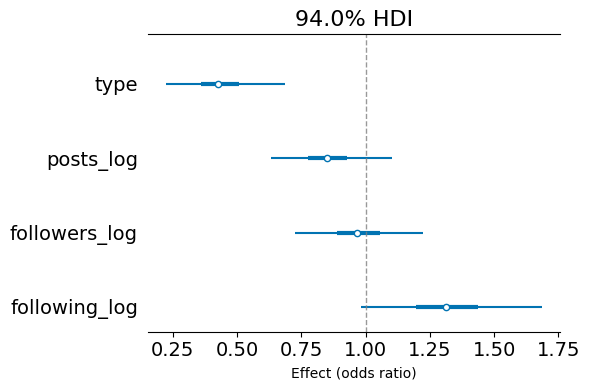

In [35]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ type + posts_log + followers_log + following_log + (1|urlid) + (1|account)",
    data=concat_df,
    family="binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(6, 4),
    r_hat=False,
    ess=False,
    var_names = ['type', 'posts_log', 'followers_log', 'following_log']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [Intercept, type, comments_count_log, posts_log, followers_log, following_log, 1|urlid_sigma, 1|urlid_offset, 1|account_sigma, 1|account_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 236 seconds.
There were 13 divergences after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.943,0.172,-2.288,-1.643,0.003,0.002,4545.0,5432.0,1.00
type[News],-1.212,0.248,-1.700,-0.763,0.004,0.003,4656.0,4710.0,1.00
comments_count_log,0.642,0.110,0.442,0.856,0.002,0.001,3818.0,4657.0,1.00
posts_log,-0.060,0.123,-0.296,0.168,0.002,0.002,5160.0,5617.0,1.00
followers_log,-0.224,0.122,-0.461,-0.000,0.002,0.002,3907.0,3360.0,1.00
...,...,...,...,...,...,...,...,...,...
1|account[peacock],-0.040,0.242,-0.538,0.429,0.003,0.005,8941.0,4375.0,1.00
1|account[thedogist],-0.137,0.244,-0.661,0.267,0.005,0.004,3122.0,4525.0,1.00
1|account[thegradecricketer],-0.066,0.262,-0.630,0.410,0.003,0.007,8084.0,3867.0,1.01
1|account[thehill],0.056,0.265,-0.446,0.594,0.003,0.006,6681.0,4659.0,1.00


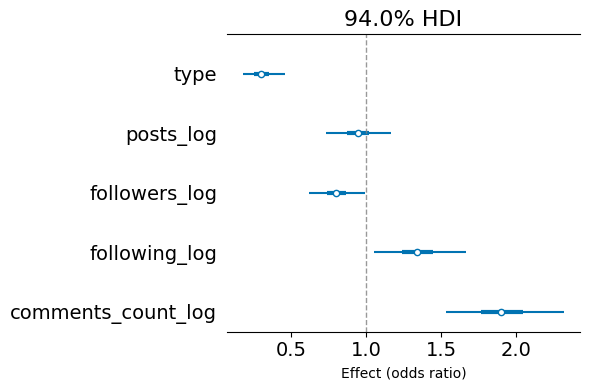

In [37]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ type + comments_count_log + posts_log + followers_log + following_log + (1|urlid) + (1|account)",
    data=concat_df,
    family="binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=4,
    random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(6, 4),
    r_hat=False,
    ess=False,
    var_names = ['type', 'posts_log', 'followers_log', 'following_log', 'comments_count_log']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [Intercept, type, comments_count_log, type:comments_count_log, posts_log, followers_log, following_log, 1|urlid_sigma, 1|urlid_offset, 1|account_sigma, 1|account_offset]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 1092 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,-1.931,0.176,-2.265,-1.599,0.003,0.002,4375.0,5319.0,1.0
type[News],-1.216,0.247,-1.695,-0.758,0.004,0.003,4791.0,5423.0,1.0
comments_count_log,0.686,0.166,0.377,0.998,0.002,0.002,4640.0,4468.0,1.0
type:comments_count_log[News],-0.073,0.217,-0.483,0.340,0.003,0.003,4609.0,4735.0,1.0
posts_log,-0.069,0.129,-0.317,0.168,0.002,0.002,5963.0,6079.0,1.0
...,...,...,...,...,...,...,...,...,...
1|account[peacock],-0.049,0.245,-0.572,0.400,0.003,0.005,8812.0,4311.0,1.0
1|account[thedogist],-0.140,0.246,-0.652,0.290,0.004,0.004,4428.0,4866.0,1.0
1|account[thegradecricketer],-0.066,0.269,-0.637,0.421,0.003,0.006,9037.0,4634.0,1.0
1|account[thehill],0.054,0.271,-0.476,0.601,0.003,0.006,9435.0,4269.0,1.0


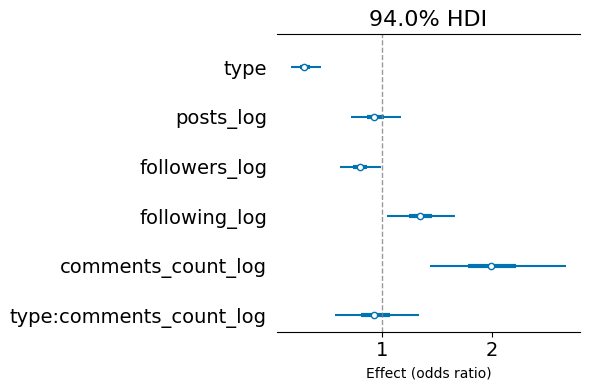

In [39]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ type * comments_count_log + posts_log + followers_log + following_log + (1|urlid) + (1|account)",
    data=concat_df,
    family="binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(6, 4),
    r_hat=False,
    ess=False,
    var_names = ['type', 'posts_log', 'followers_log', 'following_log', 'comments_count_log', 'type:comments_count_log']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

#### only political reg

In [ ]:
reg_news_df['fcount_no_rank'] = reg_news_df['fcount_no_rank'].astype(int)
reg_news_df['ftrials_no_rank'] = reg_news_df['ftrials_no_rank'].astype(int)
reg_news_df['fcount_rank'] = reg_news_df['fcount_rank'].astype(int)
reg_news_df['ftrials_rank'] = reg_news_df['ftrials_rank'].astype(int)

(reg_news_df[reg_news_df['fcount_no_rank'] > reg_news_df['ftrials_no_rank']]).shape, (reg_news_df[reg_news_df['fcount_rank'] > reg_news_df['ftrials_rank']]).shape

In [41]:
posts_data = pd.read_excel('/Users/brahmaninutakki/saarland/insta-comments/saved_data/News Sites US.xlsx', sheet_name='New data topics')
posts_data['urlid'] = posts_data['Url'].apply(lambda x: x.split('/')[-2] if x.endswith('/') else x.split('/')[-1])
posts_data = posts_data[posts_data['urlid'].isin(reg_news_df['urlid'].unique().tolist())]
posts_data.shape[0] == reg_news_df['urlid'].nunique()

reg_news_df = pd.merge(reg_news_df, posts_data, on='urlid', how='inner')
reg_news_df.drop(columns=['Url'], inplace=True)
reg_news_df.shape

(2121, 22)

In [49]:
reg_news_df['political_ideology'] = reg_news_df['political_ideology'].replace({'Right': 'Right',
                                      'Center-Left': 'Left',
                                      'Center': 'Center',
                                      'Left': 'Left',
                                      'Center-Right': 'Right'})

reg_news_df['political_ideology'].value_counts()

political_ideology
Left      941
Right     754
Center    426
Name: count, dtype: int64

In [43]:
for col in ["posts", "followers", "following", "comments_count"]:
    new = col + "_logz"
    x = np.log1p(reg_news_df[col].astype(float))
    reg_news_df[new] = (x - x.mean()) / x.std(ddof=0)



reg_news_df["gender"] = pd.Categorical(
    reg_news_df["gender"],
    categories=["female_male", "female_female", "male_male"],
    ordered=True
)

reg_news_df["ideology"] = pd.Categorical(
    reg_news_df["ideology"],
    categories=["dem_rep", "dem_dem", "rep_rep"],
    ordered=True
)

reg_news_df["location"] = pd.Categorical(
    reg_news_df["location"],
    categories=["ny_texas", "ny_ny", "texas_texas"],
    ordered=True
)

reg_news_df['type'] = pd.Categorical(
    reg_news_df['type'],
    categories=['Non-News', 'News'],
    ordered=True
)

reg_news_df['main_topic'] = pd.Categorical(
    reg_news_df['main_topic'],
    categories=['Non-Political', 'Political'],
    ordered=True
)

In [44]:
reg_news_df.head()

,location,gender,ideology,urlid,account,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,political_ideology,reporting_quality,credibility,posts,followers,following,comments_count,likes_count,type,Brahmani_Topics,Divya_Topics,Hamayoon_Topics,main_topic,posts_logz,followers_logz,following_logz,comments_count_logz
0,ny_texas,male_male,dem_dem,DRK7-xAEaGg,thehill,0.0,18.0,2.0,9.0,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,News,Political,Political,Political,Political,0.037847,-2.151584,-2.106627,-0.40706
1,ny_ny,male_male,dem_rep,DRK7-xAEaGg,thehill,3.0,19.0,5.0,10.0,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,News,Political,Political,Political,Political,0.037847,-2.151584,-2.106627,-0.40706
2,ny_texas,male_male,dem_rep,DRK7-xAEaGg,thehill,3.0,19.0,5.0,10.0,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,News,Political,Political,Political,Political,0.037847,-2.151584,-2.106627,-0.40706
3,ny_ny,female_male,dem_dem,DRK7-xAEaGg,thehill,0.0,18.0,0.0,9.0,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,News,Political,Political,Political,Political,0.037847,-2.151584,-2.106627,-0.40706
4,ny_texas,female_male,dem_dem,DRK7-xAEaGg,thehill,0.0,18.0,0.0,9.0,Center,Mostly Factual,High,5316.0,304000,53,180.0,NaN,News,Political,Political,Political,Political,0.037847,-2.151584,-2.106627,-0.40706


In [57]:
reg_news_df.describe()

,fcount_no_rank,ftrials_no_rank,fcount_rank,ftrials_rank,posts,followers,following,comments_count,likes_count,posts_logz,followers_logz,following_logz,comments_count_logz
count,2121.000000,2121.000000,2121.000000,2121.000000,2121.000000,2.121000e+03,2121.000000,2121.000000,1394.000000,2.121000e+03,2.121000e+03,2.121000e+03,2.121000e+03
mean,1.646393,19.617162,4.367280,9.942480,26028.342966,6.594082e+06,279.653465,1187.509665,12646.604735,-5.896064e-16,-8.710095e-16,3.752041e-16,3.886042e-16
std,2.192482,1.685277,2.752262,0.411499,23875.652278,6.559318e+06,176.585399,2545.964463,20704.422366,1.000236e+00,1.000236e+00,1.000236e+00,1.000236e+00
min,0.000000,10.000000,0.000000,5.000000,16.790000,3.040000e+05,53.000000,14.000000,500.000000,-1.781523e+00,-2.151584e+00,-2.106627e+00,-1.989810e+00
25%,0.000000,20.000000,2.000000,10.000000,5316.000000,2.000000e+06,163.000000,106.000000,2000.000000,3.784718e-02,-5.443314e-01,-4.816963e-01,-7.411375e-01
50%,2.000000,20.000000,4.000000,10.000000,24022.000000,3.300000e+06,289.000000,352.000000,4900.000000,5.192126e-01,-1.170880e-01,3.520858e-01,1.745431e-02
75%,2.000000,20.000000,7.000000,10.000000,34864.000000,7.300000e+06,317.000000,1100.000000,11700.000000,6.381004e-01,5.602832e-01,4.869071e-01,7.403719e-01
max,12.000000,20.000000,10.000000,10.000000,70290.000000,2.170000e+07,708.000000,15100.000000,126900.000000,8.619010e-01,1.489753e+00,1.659737e+00,2.404530e+00


In [54]:
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + C(political_ideology) + C(reporting_quality) + C(credibility) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + C(political_ideology) + C(main_topic) + posts_logz + followers_logz + following_logz + comments_count_logz" 
formula = "fcount_no_rank ~ C(location) + C(gender) + C(ideology) + C(political_ideology) + C(main_topic) + posts_logz + followers_logz + comments_count_logz" 
get_vif(formula, reg_news_df)

,feature,VIF
4,C(gender)[T.male_male],1.149774
3,C(gender)[T.female_female],1.151444
5,C(ideology)[T.dem_dem],1.151479
6,C(ideology)[T.rep_rep],1.151623
1,C(location)[T.ny_ny],1.174789
2,C(location)[T.texas_texas],1.175032
12,comments_count_logz,1.458183
9,C(main_topic)[T.Political],1.591883
11,followers_logz,1.773111
10,posts_logz,1.984251


In [59]:
model = bmb.Model(
    "p(fcount_no_rank, ftrials_no_rank) ~ location + gender + ideology + political_ideology + main_topic + posts_logz + followers_logz + comments_count_logz + (1|urlid) + (1|account)",
    data=reg_news_df,
    family="beta_binomial",
    # dropna=True
)

results = model.fit(
    draws=2000,      
    tune=2000,       
    target_accept=0.97,
    chains=4,
    cores=1,
    random_seed=42,
)
display(az.summary(results))

axes = az.plot_forest(
    results,
    combined=True,
    hdi_prob=0.94,
    transform=np.exp,
    figsize=(6, 4),
    r_hat=False,
    ess=False,
    # var_names = ['type', 'posts_log', 'followers_log', 'following_log', 'comments_count_log', 'type:comments_count_log']
)

ax = axes[0] if isinstance(axes, (list, np.ndarray)) else axes

ax.axvline(1, linestyle="--", linewidth=1, color="grey", alpha=0.8)
ax.set_xlabel("Effect (odds ratio)")
plt.tight_layout()
plt.show()

Initializing NUTS using jitter+adapt_diag...
Sequential sampling (4 chains in 1 job)
NUTS: [kappa, Intercept, location, gender, ideology, political_ideology, main_topic, posts_logz, followers_logz, comments_count_logz, 1|urlid_sigma, 1|urlid_offset, 1|account_sigma, 1|account_offset]


Output()